# Data Mining And Visualization Project

# Data Information and statistics

##### Importing the relevant libraries
Also, setting settings for graph displays and reading the data into DataFrame

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
%matplotlib inline
sns.set(color_codes=True) 
sns.set(rc={'figure.figsize':(5,5)}) 

In [3]:
train_df = pd.read_csv("hotels_train.csv")


#### Data visualisations:

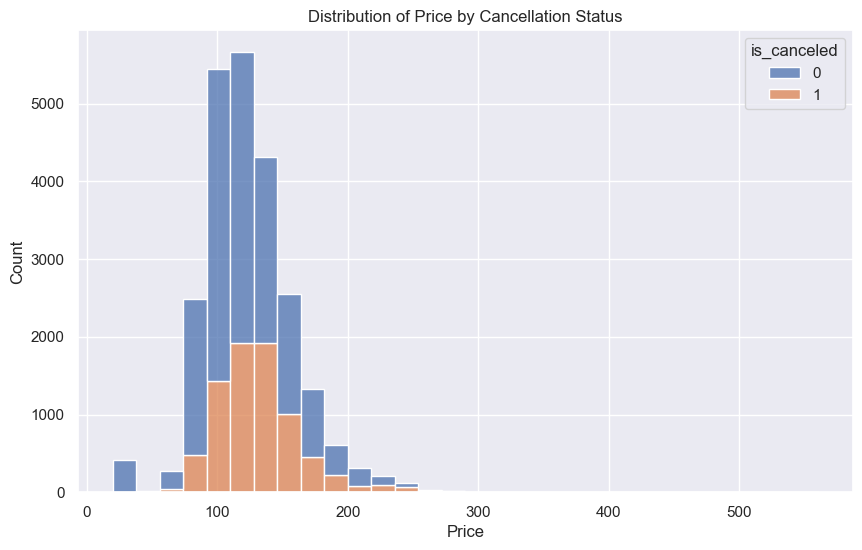

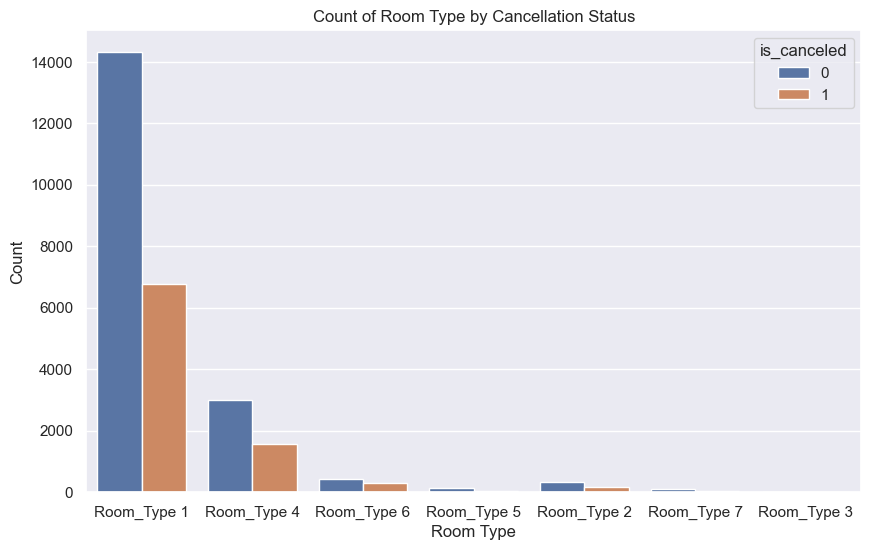

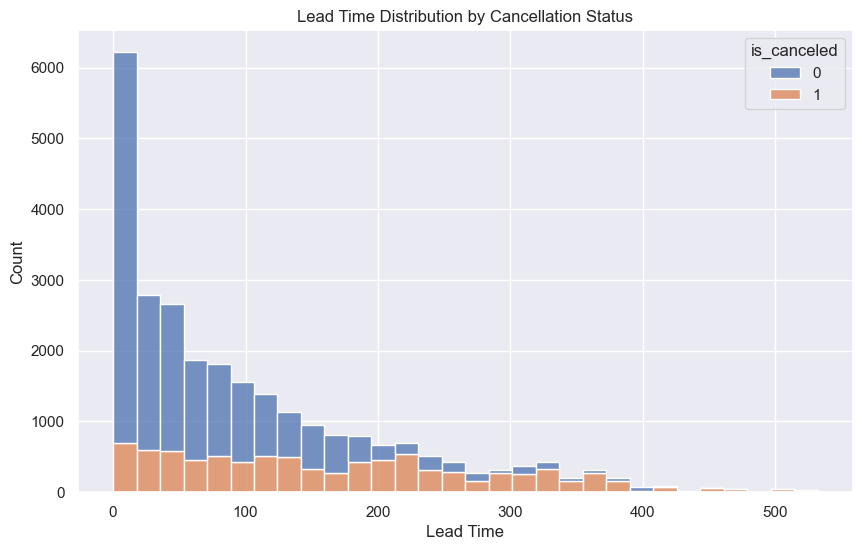

In [4]:
vis_df = train_df.copy()
# Distribution of price by is_canceled
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='price', hue='is_canceled', multiple='stack', bins=30)
plt.title('Distribution of Price by Cancellation Status')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# Count of room_type by is_canceled
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='room_type', hue='is_canceled')
plt.title('Count of Room Type by Cancellation Status')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

# Lead time distribution by is_canceled
plt.figure(figsize=(10, 6))
sns.histplot(data=vis_df, x='lead_time', hue='is_canceled', multiple='stack', bins=30)
plt.title('Lead Time Distribution by Cancellation Status')
plt.xlabel('Lead Time')
plt.ylabel('Count')
plt.show()


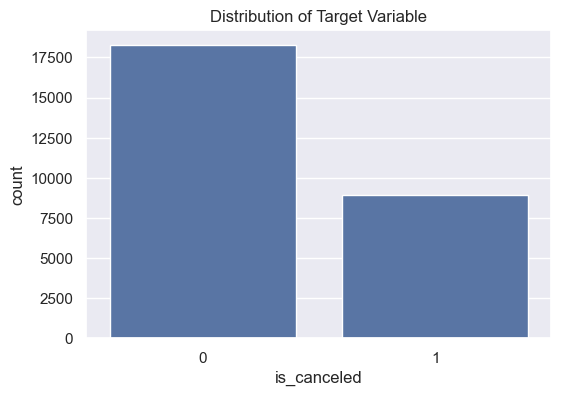

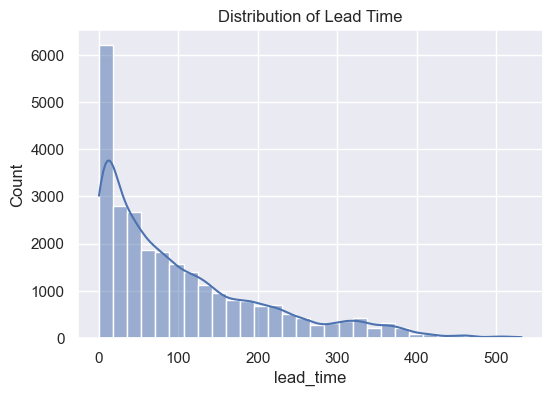

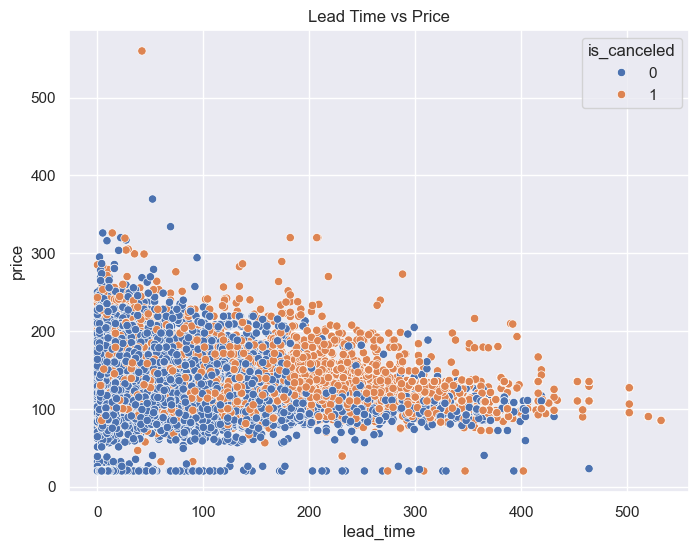

In [5]:

# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=train_df)
plt.title('Distribution of Target Variable')
plt.show()

# Example of feature distribution
plt.figure(figsize=(6, 4))
sns.histplot(train_df['lead_time'], bins=30, kde=True)
plt.title('Distribution of Lead Time')
plt.show()

# Scatter plot of lead time vs price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='lead_time', y='price', hue='is_canceled', data=train_df)
plt.title('Lead Time vs Price')
plt.show()

## Info

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27213 entries, 0 to 27212
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   27213 non-null  object 
 1   weekend_nights       27213 non-null  int64  
 2   week_nights          27213 non-null  int64  
 3   room_type            27213 non-null  object 
 4   board_type           19045 non-null  object 
 5   n_adults             27213 non-null  int64  
 6   n_less_12            27213 non-null  int64  
 7   n_more_12            27213 non-null  int64  
 8   booked_tour          27213 non-null  int64  
 9   n_requests           27213 non-null  int64  
 10  lead_time            26794 non-null  float64
 11  purchase_type        22366 non-null  object 
 12  n_p_cacellation      27213 non-null  int64  
 13  n_p_not_cacellation  27213 non-null  int64  
 14  repeated             27213 non-null  int64  
 15  price                23808 non-null 

In [7]:
train_df.describe()

,weekend_nights,week_nights,n_adults,n_less_12,n_more_12,booked_tour,n_requests,lead_time,n_p_cacellation,n_p_not_cacellation,repeated,price,is_canceled
count,27213.000000,27213.000000,27213.000000,27213.000000,27213.000000,27213.000000,27213.000000,26794.000000,27213.000000,27213.000000,27213.000000,23808.000000,27213.000000
mean,0.812810,2.197332,1.845221,0.052989,0.053357,0.031750,0.621100,102.952377,0.021975,0.155404,0.026421,123.455494,0.327674
std,0.869317,1.403576,0.519715,0.266150,0.268688,0.175336,0.785642,103.498942,0.346697,1.728693,0.160387,35.136566,0.469374
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,100.300000,0.000000
50%,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000000,0.000000,0.000000,119.450000,0.000000
75%,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,1.000000,153.000000,0.000000,0.000000,0.000000,140.000000,1.000000
max,7.000000,17.000000,4.000000,6.000000,4.000000,1.000000,5.000000,532.000000,13.000000,57.000000,1.000000,560.000000,1.000000


Showing the possible amount of values in a column and determining the types

In [8]:
# Print unique values for each column to help identify their types
for column in train_df.columns:
    print(f"Unique values in {column}:{len(vis_df[column].unique())}")

Unique values in ID:27213
Unique values in weekend_nights:8
Unique values in week_nights:18
Unique values in room_type:7
Unique values in board_type:5
Unique values in n_adults:5
Unique values in n_less_12:5
Unique values in n_more_12:5
Unique values in booked_tour:2
Unique values in n_requests:6
Unique values in lead_time:351
Unique values in purchase_type:6
Unique values in n_p_cacellation:8
Unique values in n_p_not_cacellation:50
Unique values in repeated:2
Unique values in price:3163
Unique values in date:553
Unique values in is_canceled:2


By the amount of possible values in each column we can determine:


In [9]:
# Numerical Columns
numerical_columns = ['n_adults', 'n_less_12', 'n_more_12', 'weekend_nights', 'week_nights', 'lead_time', 'price', 'n_requests', 'n_p_cacellation', 'n_p_not_cacellation']

# Binary Columns
binary_columns = ['booked_tour', 'repeated', 'is_canceled']

# Categorical Columns
categorical_columns = ['board_type', 'room_type', 'purchase_type']

#### Skewness

In [10]:
# Calculate skewness for each numerical column
numerical_columns_df = train_df[numerical_columns]
skewness = numerical_columns_df.skew()

# Display skewness
print(skewness)

n_adults               -0.324161
n_less_12               5.749665
n_more_12               5.569096
weekend_nights          0.718789
week_nights             1.542295
lead_time               1.291447
price                   0.682393
n_requests              1.143745
n_p_cacellation        26.069040
n_p_not_cacellation    19.076806
dtype: float64


# Pre-processing

### Missing values

In [11]:
train_df.isnull().sum()

ID                        0
weekend_nights            0
week_nights               0
room_type                 0
board_type             8168
n_adults                  0
n_less_12                 0
n_more_12                 0
booked_tour               0
n_requests                0
lead_time               419
purchase_type          4847
n_p_cacellation           0
n_p_not_cacellation       0
repeated                  0
price                  3405
date                      0
is_canceled               0
dtype: int64

Missing Values:

1. board_type (object) :missing 8168, about 1/3 of the values are missing.
2. lead_time (float) : 419 missing
3. purchase_type (object) : missing 4847 
4. price (float) : missing 3405 


##### Finding inforamation about missing values

In [12]:
specific_features = ['board_type', 'lead_time', 'purchase_type', 'price']
train_df[specific_features].describe(include='all')

,board_type,lead_time,purchase_type,price
count,19045,26794.000000,22366,23808.000000
unique,4,NaN,5,NaN
top,half board,NaN,Online,NaN
freq,14591,NaN,14306,NaN
mean,NaN,102.952377,NaN,123.455494
std,NaN,103.498942,NaN,35.136566
min,NaN,0.000000,NaN,20.000000
25%,NaN,21.000000,NaN,100.300000
50%,NaN,69.000000,NaN,119.450000
75%,NaN,153.000000,NaN,140.000000


#### Finding correlation

In [13]:
# Attempt to parse the date column with multiple formats
vis_df['date'] = pd.to_datetime(vis_df['date'], errors='coerce', format='%Y-%m-%d')
vis_df['date'].fillna(pd.to_datetime(vis_df['date'], format='%m/%d/%Y', errors='coerce'))

# Add 'month_year' column for analysis
vis_df['month_year'] = vis_df['date'].dt.to_period('M')

# Columns to be label encoded
columns_to_encode = ['room_type', 'board_type', 'purchase_type']

# Initialize LabelEncoder
le = LabelEncoder()


# Apply LabelEncoder to specified columns
for col in columns_to_encode:
    vis_df[col] = le.fit_transform(vis_df[col].astype(str))

# Drop the original date column as we've extracted relevant features
vis_df.drop(columns=['date'], inplace=True)


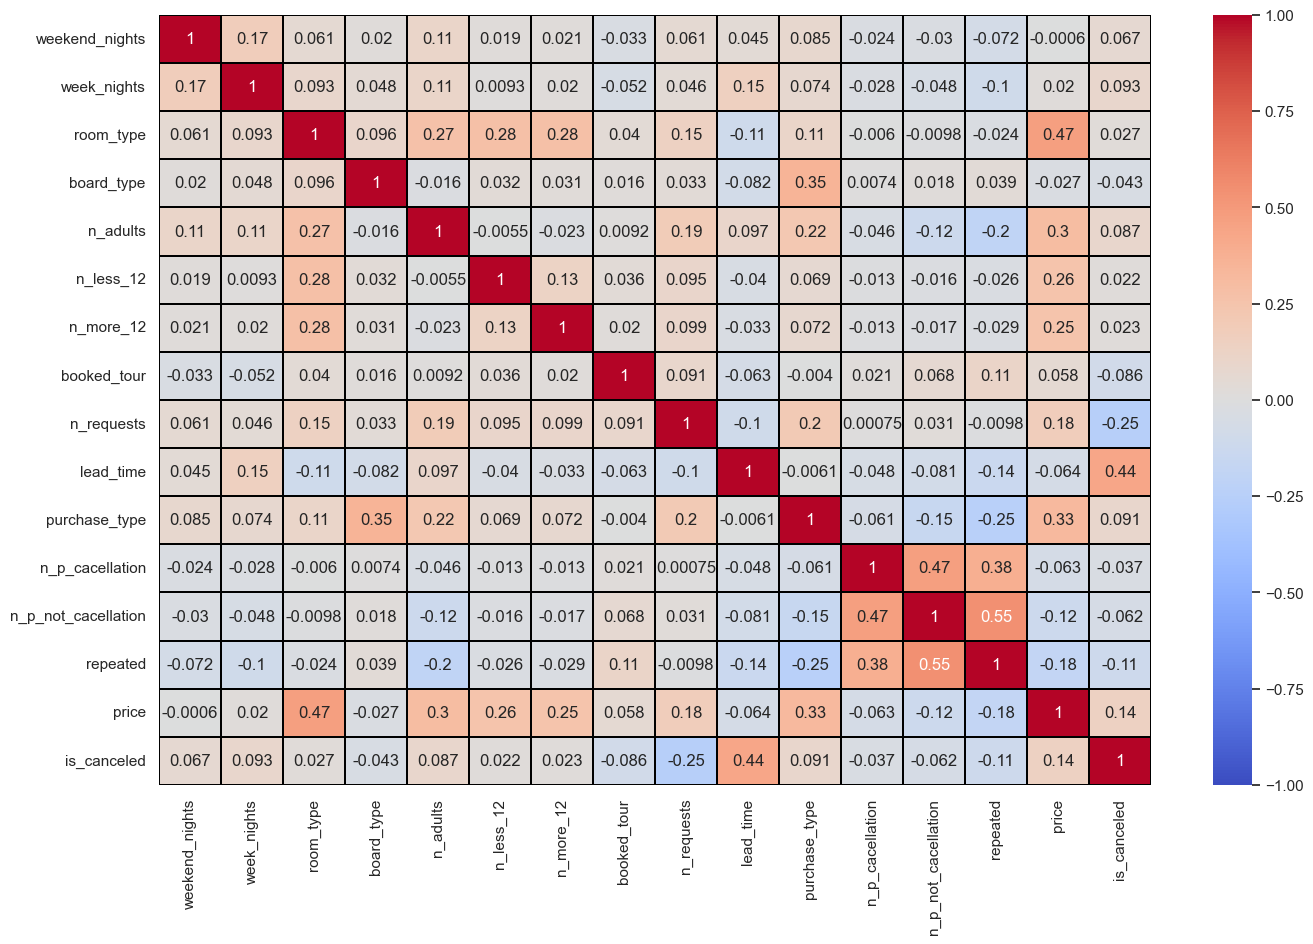

In [14]:
f, ax = plt.subplots(figsize=(16, 10))
ax = sns.heatmap(vis_df[vis_df.describe().columns].corr(), annot = True, vmin=-1, vmax=1, center= 0,
            cmap= 'coolwarm', linewidths=0.2, linecolor='black')

We can see that the target value (is_canceled) is corrolated to the value lead_time
Also, we can see that:
1. Price is corolated to room_type
2. Board type is corolated by purchase type

#### board_type
This is a catagorial feature.
 about 8168 of the values are missing.

['half board' nan 'full board' 'breakfast' 'not selected']


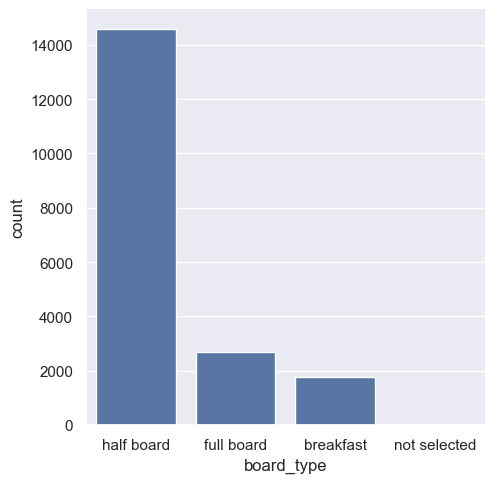

In [15]:
print(train_df['board_type'].unique())
sns.catplot(x = 'board_type', kind = 'count', data = train_df)

This feature has only 3 optional values

for now: filling with missing

In [16]:
train_df['board_type'] = train_df['board_type'].fillna('missing')

['half board' 'missing' 'full board' 'breakfast' 'not selected']


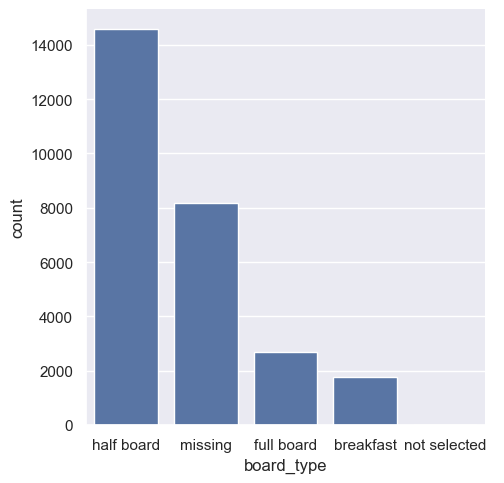

In [17]:
print(train_df['board_type'].unique())
sns.catplot(x = 'board_type', kind = 'count', data = train_df)

#### lead_time
This is a Nomerical feature.

Small amount of values, because of the variance in the data, I choose to fill the null values with the median

In [18]:
# Calculate the median lead time
LT_median = train_df['lead_time'].median()

# Fill missing values in the lead_time column with the median
train_df['lead_time'] = train_df['lead_time'].fillna(LT_median)
print(f"null amount in 'lead_time' : {train_df['lead_time'].isnull().sum()}")

null amount in 'lead_time' : 0


#### purchase_type

This is a categorical attribute and it has 1,611 missing values , 17.7%.

In [19]:
train_df['purchase_type'].unique()

array(['Online', nan, 'Offline', 'Corporate', 'Complementary', 'Aviation'],
      dtype=object)

This feature has 5 optional values

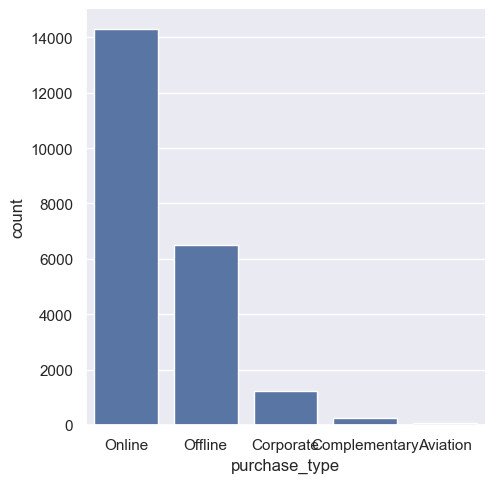

In [20]:
sns.catplot(x = 'purchase_type', kind = 'count', data = train_df)

For now: fill with 'missing'

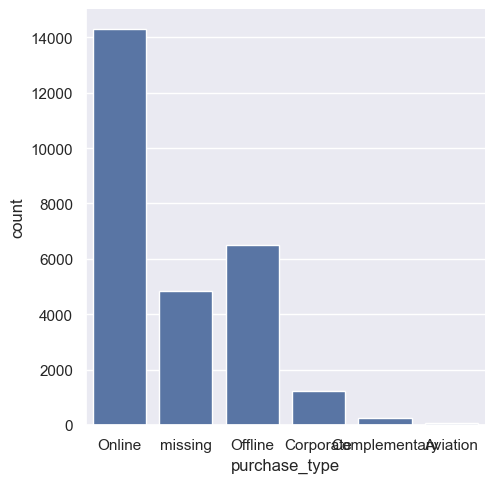

In [21]:
train_df['purchase_type'] = train_df['purchase_type'].fillna('missing')
sns.catplot(x = 'purchase_type', kind = 'count', data = train_df)

#### Price
This is a Nomerical feature missing 1,130 values , 12.5%

count    23808.000000
mean       123.455494
std         35.136566
min         20.000000
25%        100.300000
50%        119.450000
75%        140.000000
max        560.000000
Name: price, dtype: float64

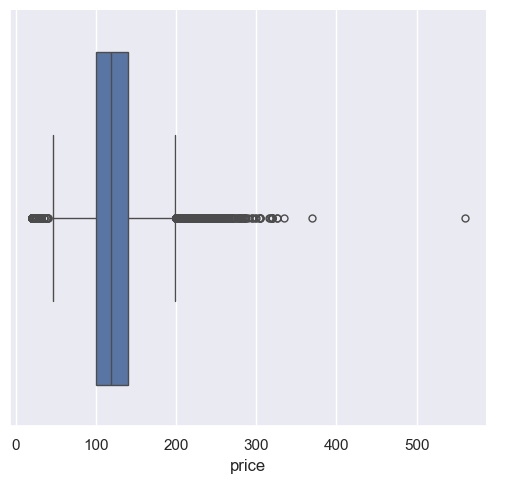

In [22]:
sns.catplot(x = 'price', kind = 'box', data = train_df)
train_df['price'].describe(include='all')

price has corrolation to room type

In [23]:
arr = (train_df['room_type'].unique())
arr

array(['Room_Type 1', 'Room_Type 4', 'Room_Type 6', 'Room_Type 5',
       'Room_Type 2', 'Room_Type 7', 'Room_Type 3'], dtype=object)

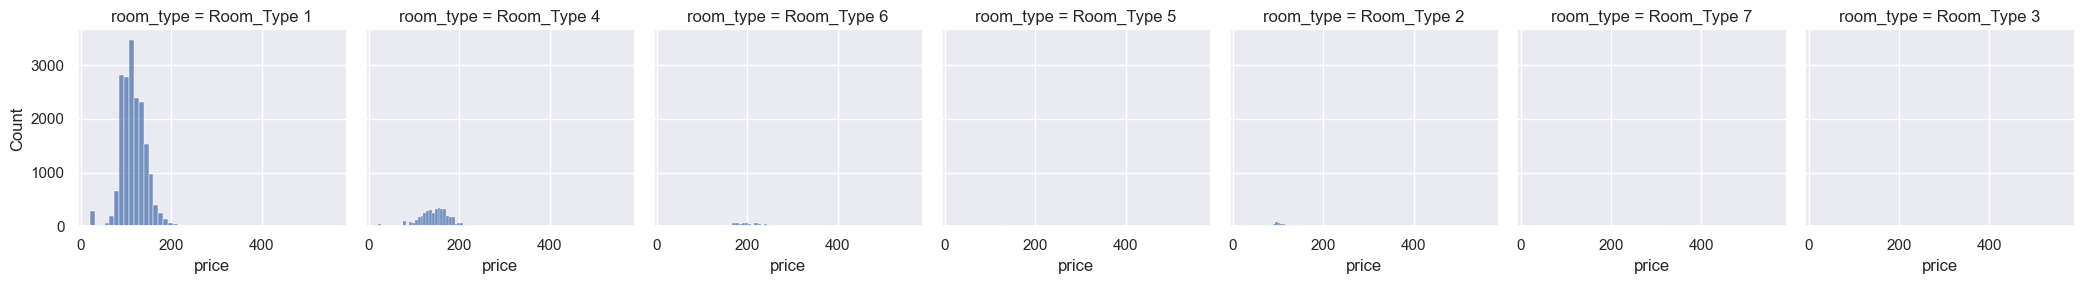

In [24]:
g = sns.FacetGrid(train_df, col ='room_type')
g.map_dataframe(sns.histplot, x = 'price', bins = 50)

We can see the other the room_type 2, 6 price is disturbuited normally

In [25]:
# Iterate over each unique room type in the 'room_type' column of train_df
for Rtype in train_df['room_type'].unique():
    # Count the total number of entries for the current room type
    count_total = (train_df['room_type'] == Rtype).sum()
    # Count the number of entries with null values in the 'price' field for the current room type
    count_null_price = train_df[(train_df['room_type'] == Rtype) & (train_df['price'].isnull())].shape[0]
    # Print the results for the current room type
    print(f"In {Rtype}, there are {count_total} entries, with {count_null_price} having null in the 'price' field.")

In Room_Type 1, there are 21084 entries, with 2634 having null in the 'price' field.
In Room_Type 4, there are 4571 entries, with 585 having null in the 'price' field.
In Room_Type 6, there are 741 entries, with 100 having null in the 'price' field.
In Room_Type 5, there are 180 entries, with 24 having null in the 'price' field.
In Room_Type 2, there are 511 entries, with 55 having null in the 'price' field.
In Room_Type 7, there are 123 entries, with 7 having null in the 'price' field.
In Room_Type 3, there are 3 entries, with 0 having null in the 'price' field.


we can use the mean of price for each room type to replace null values in the 'price' catagory 
1. for room_type 3 , no nulls in the 'price' column 
2. for room type 7,2,5,6 fill the null values with mean 
3. for room type 1,4 fill the null with normally disterbuited values

In [26]:
fill_with_mean = ['Room_Type 7','Room_Type 2','Room_Type 5','Room_Type 6']
fill_with_normal = ['Room_Type 1','Room_Type 4']
# finding the disterbutions
mu1 = train_df.loc[train_df['room_type']=='Room_Type 1' , 'price'].mean()
sigma1 = train_df.loc[train_df['room_type']=='Room_Type 1' , 'price'].std()

mu4 = train_df.loc[train_df['room_type']=='Room_Type 4' , 'price'].mean()
sigma4 = train_df.loc[train_df['room_type']=='Room_Type 4' , 'price'].std()

# filling the values:
def fill_missing_price1(row):
    if pd.isna(row['price']) and row['room_type'] == 'Room_Type 1':
        return np.random.normal(mu1, sigma1)
    else:
        return row['price']

train_df['price'] =train_df.apply(fill_missing_price1, axis =1  )

def fill_missing_price4(row):
    if pd.isna(row['price']) and row['room_type'] == 'Room_Type 4':
        return np.random.normal(mu4, sigma4)
    else:
        return row['price']

train_df['price'] =train_df.apply(fill_missing_price4, axis =1  )

# filling with mean:
for type_room in fill_with_mean:
    mean_price = train_df.loc[train_df['room_type'] == type_room, 'price'].mean()
    train_df.loc[(train_df['room_type'] == type_room) & (train_df['price'].isnull()), 'price'] = mean_price

print(f"Nulls in 'price' : {train_df['price'].isnull().sum()}")

Nulls in 'price' : 0


In [27]:
train_df.isnull().sum()

ID                     0
weekend_nights         0
week_nights            0
room_type              0
board_type             0
n_adults               0
n_less_12              0
n_more_12              0
booked_tour            0
n_requests             0
lead_time              0
purchase_type          0
n_p_cacellation        0
n_p_not_cacellation    0
repeated               0
price                  0
date                   0
is_canceled            0
dtype: int64

All null values are filled

### Outliers

Fiding the outliars in the catagorial columns:

In [28]:
for column in categorical_columns:
    print(train_df[column].value_counts())

board_type
half board      14591
missing          8168
full board       2697
breakfast        1753
not selected        4
Name: count, dtype: int64
room_type
Room_Type 1    21084
Room_Type 4     4571
Room_Type 6      741
Room_Type 2      511
Room_Type 5      180
Room_Type 7      123
Room_Type 3        3
Name: count, dtype: int64
purchase_type
Online           14306
Offline           6501
missing           4847
Corporate         1238
Complementary      244
Aviation            77
Name: count, dtype: int64


We can see 'not selected' in board_type and 'Room_type 3' in room_type are outliers in the catagorial columns

Let's look at the binary columns:

In [29]:
for column in binary_columns:
    print(train_df[column].value_counts())

booked_tour
0    26349
1      864
Name: count, dtype: int64
repeated
0    26494
1      719
Name: count, dtype: int64
is_canceled
0    18296
1     8917
Name: count, dtype: int64


Note: room_type is corolated to 'price', and board_type to 'purchase_type'. We can use these to take care of the outliers

In [30]:
# Calculate the mean price for each room type
mean_price_per_room_type = train_df.groupby('room_type')['price'].mean().reset_index()
# Display the mean price for each room type
print("Mean price for each room type:")
print(mean_price_per_room_type)

# display price for 'Room_type 3'
room_type_3_data = train_df[train_df['room_type'] == 'Room_Type 3']
print(f"Unique prices for 'Room_type 3':{room_type_3_data['price'].unique()}")

Mean price for each room type:
     room_type       price
0  Room_Type 1  115.958544
1  Room_Type 2  108.926754
2  Room_Type 3  111.916667
3  Room_Type 4  145.651345
4  Room_Type 5  143.667179
5  Room_Type 6  200.254805
6  Room_Type 7  174.058966
Unique prices for 'Room_type 3':[ 85.   100.75 150.  ]


In [31]:
filtered_df = train_df[train_df['room_type'] != 'Room_Type 3']
mean_prices = train_df.groupby('room_type')['price'].mean()
print(train_df['room_type'].value_counts())
# Function to find the closest room type based on price
def find_closest_room_type(price):
    return mean_prices.sub(price).abs().idxmin()

# Update the room_type for rows where room_type is Room_Type 3
train_df.loc[train_df['room_type'] == 'Room_Type 3', 'room_type'] = train_df.loc[train_df['room_type'] == 'Room_Type 3', 'price'].apply(find_closest_room_type)

# Verify the change
print(train_df['room_type'].value_counts())

room_type
Room_Type 1    21084
Room_Type 4     4571
Room_Type 6      741
Room_Type 2      511
Room_Type 5      180
Room_Type 7      123
Room_Type 3        3
Name: count, dtype: int64
room_type
Room_Type 1    21084
Room_Type 4     4572
Room_Type 6      741
Room_Type 2      513
Room_Type 5      180
Room_Type 7      123
Name: count, dtype: int64


Since we have a 'missing' catagory board type, we can use it to deal with the outliers

In [32]:
train_df['board_type'] = train_df['board_type'].replace('not selected', 'missing')

Numerical columns:

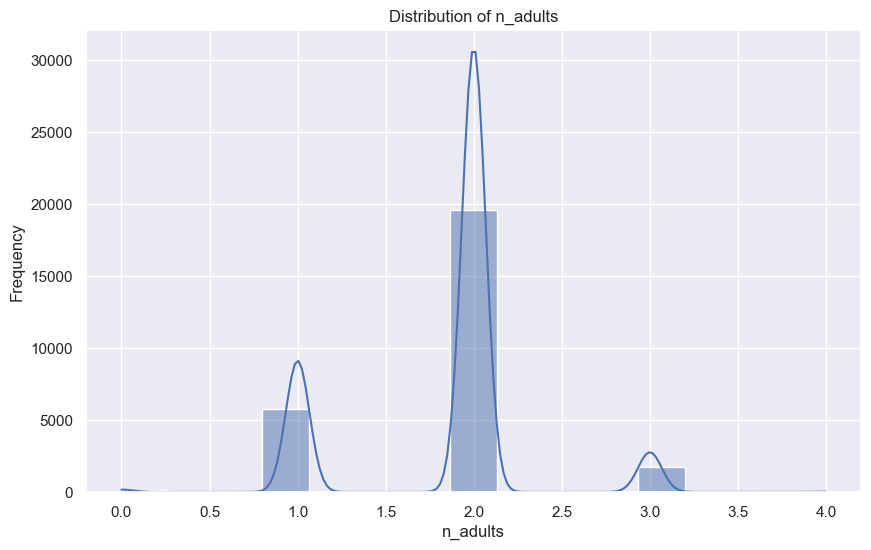

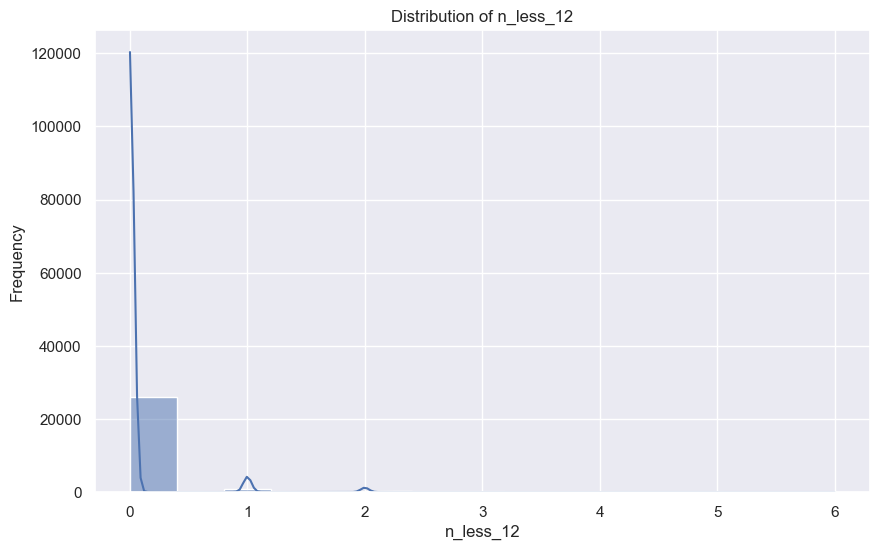

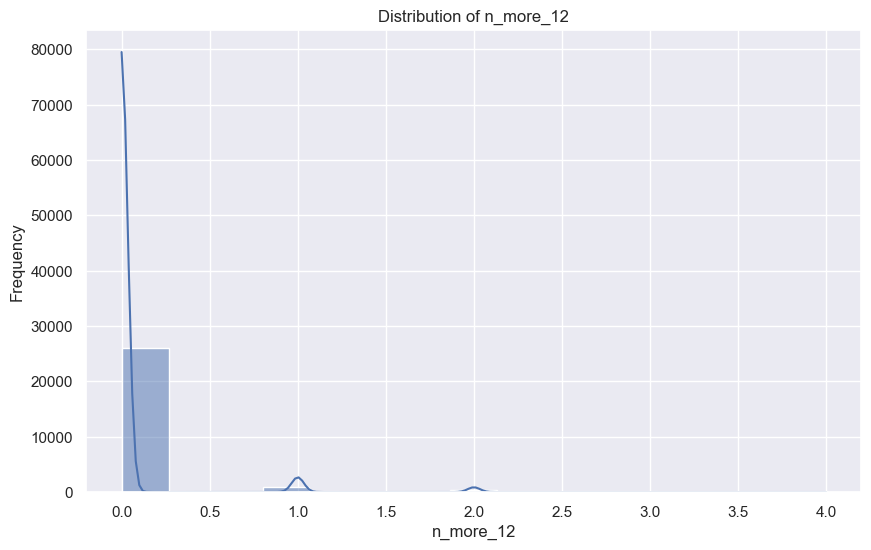

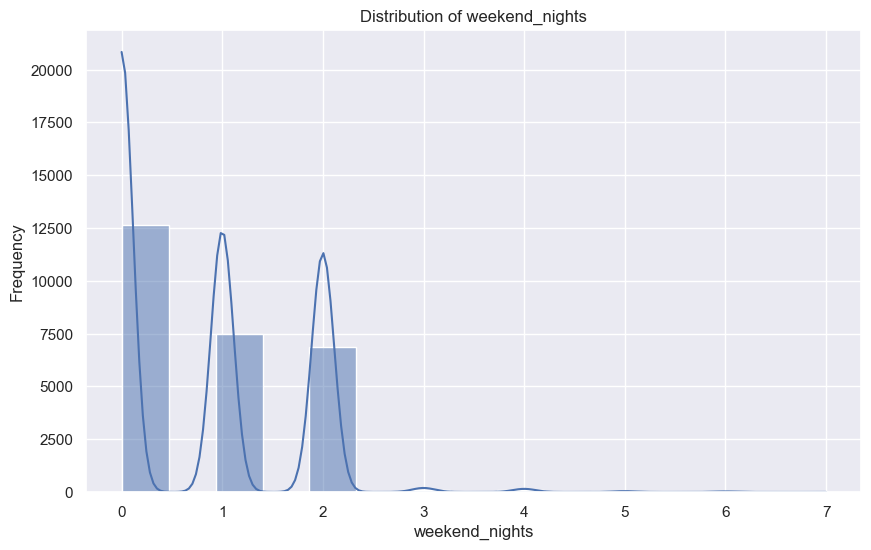

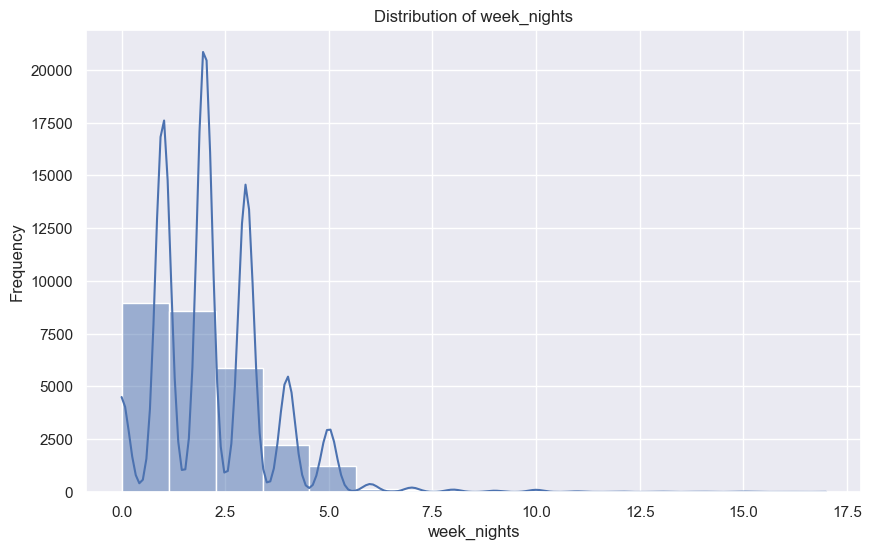

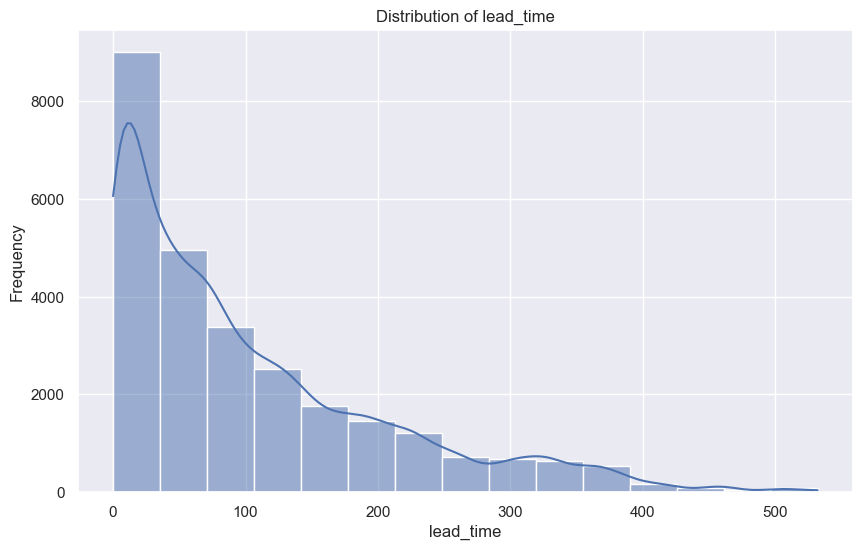

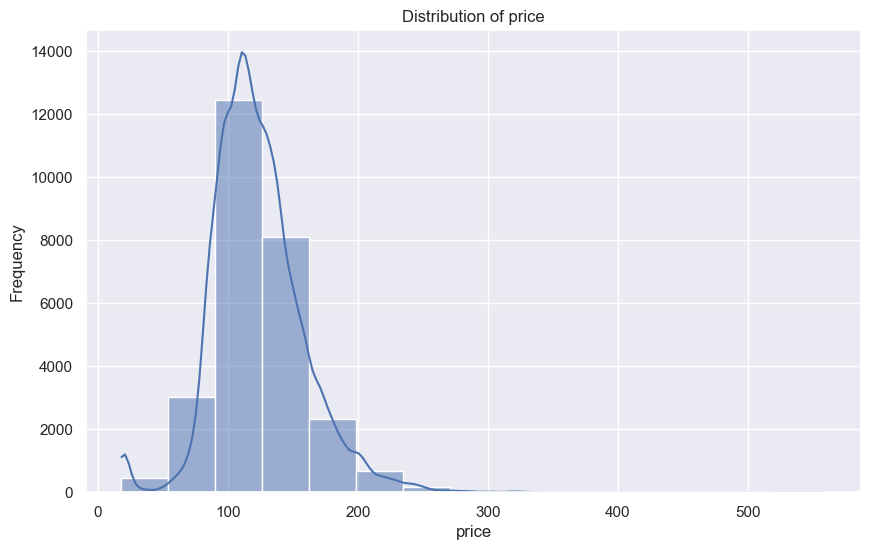

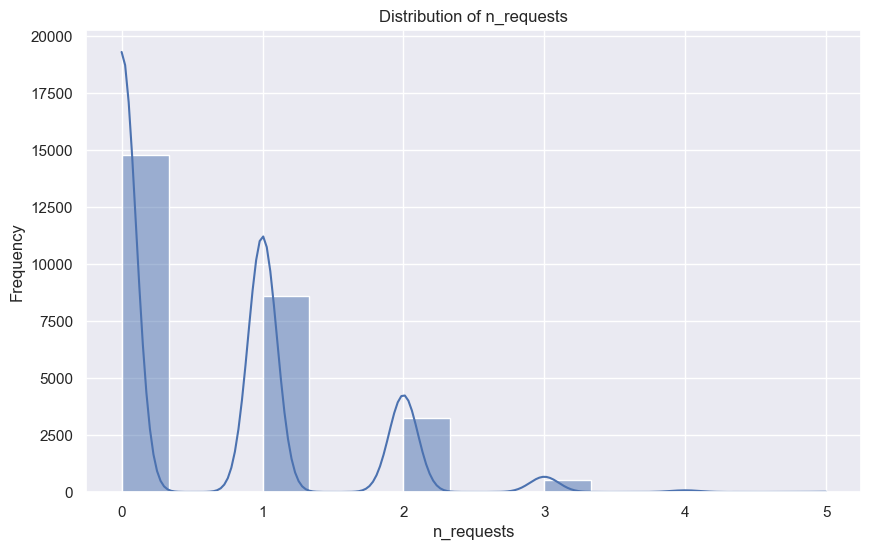

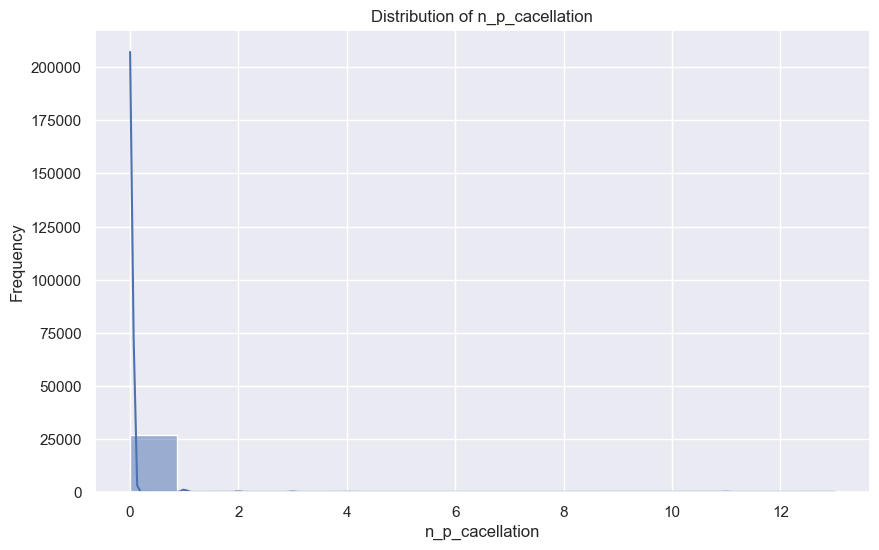

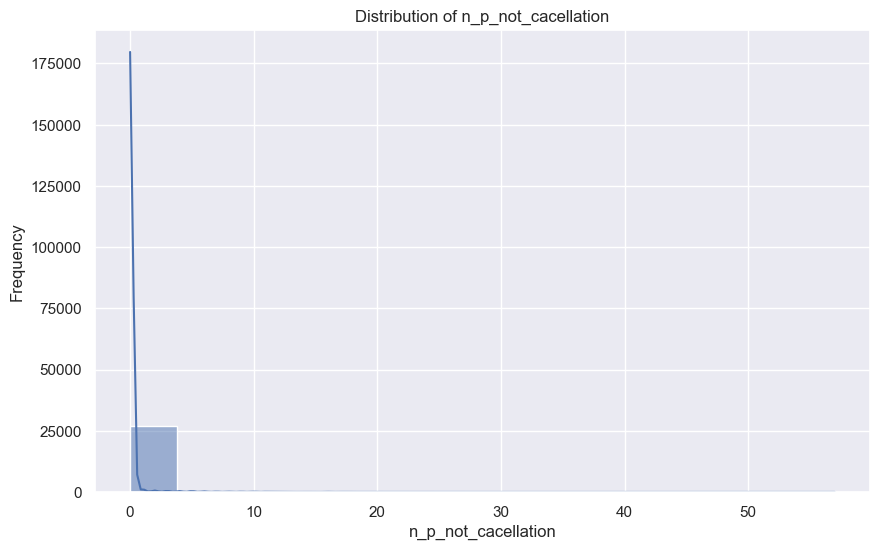

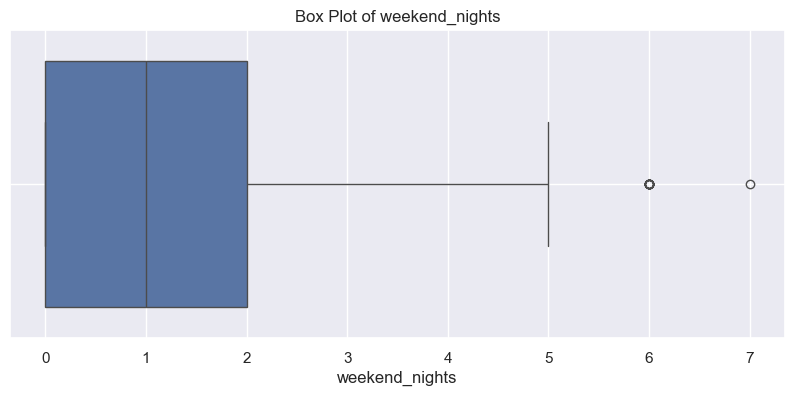

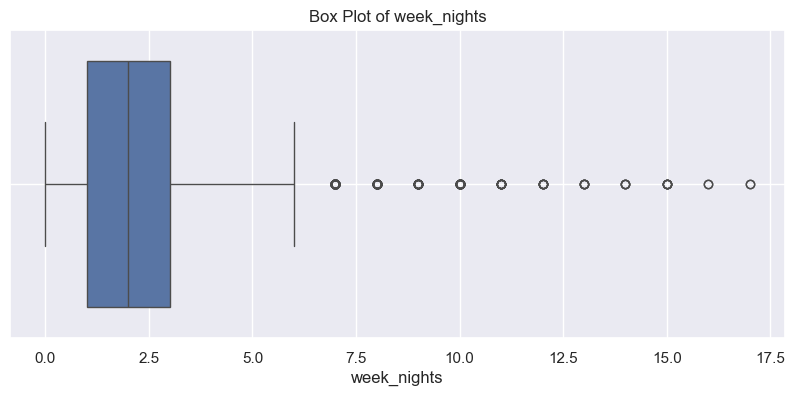

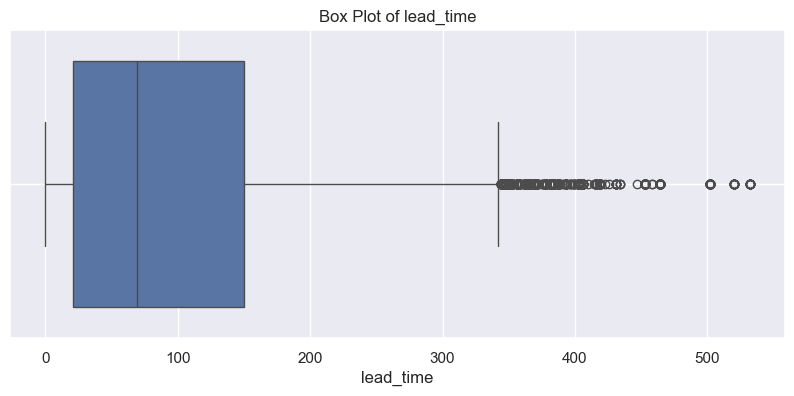

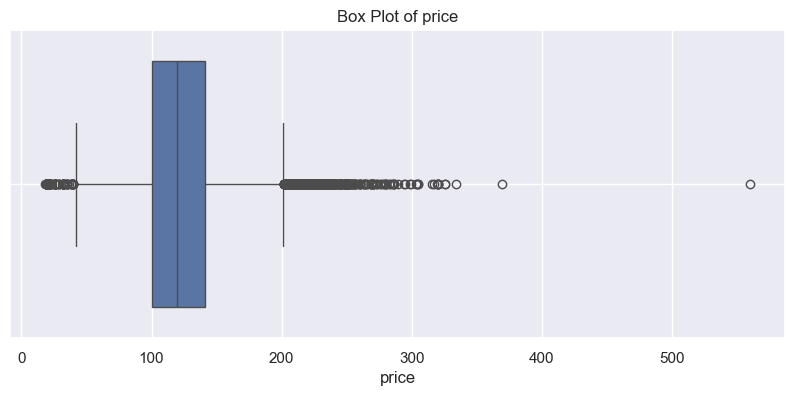

In [33]:
count_columns = ['weekend_nights', 'week_nights', 'lead_time', 'price']
# Visualize the distribution of numerical columns using histograms
for column in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(train_df[column], bins=15, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# Visualize the distribution of numerical columns using box plots
for column in count_columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=train_df[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.grid(True)
    plt.show()

### Adding columns

I choose to add 'length' which is the length in nights (weekend+week days)

In [34]:
train_df['length'] = train_df['week_nights'] + train_df['weekend_nights']

# Print counts of the values in the 'length' column
length_counts = train_df['length'].value_counts().sort_index()
print(length_counts)

length
0       59
1     4969
2     6374
3     7523
4     4394
5     1950
6      785
7      724
8      145
9       82
10      80
11      30
12      15
13      13
14      22
15      19
16       4
17       4
18       3
19       4
20       8
21       2
22       2
23       1
24       1
Name: count, dtype: int64


add check for 0

### inconsistency
Looking for ininconsistencies in the data

In [35]:
vis_df = train_df.copy()

Looking for same order IDs

In [36]:
print(f"Sum of unique IDs {train_df['ID'].nunique()}")
print(f"Lines in DF: {len(train_df)}")

Sum of unique IDs 27213
Lines in DF: 27213


Same amount of ID and lines in the data

In [37]:
for column in categorical_columns:
    print(f"Catagories in {column} : {train_df[column].unique()}")

Catagories in board_type : ['half board' 'missing' 'full board' 'breakfast']
Catagories in room_type : ['Room_Type 1' 'Room_Type 4' 'Room_Type 6' 'Room_Type 5' 'Room_Type 2'
 'Room_Type 7']
Catagories in purchase_type : ['Online' 'missing' 'Offline' 'Corporate' 'Complementary' 'Aviation']


We can see not catagories that are alike in spelling, all are real catagories.

### Normalization

We have two numerical columns with wide spread of values that we should normalize

Lead Time: is skewed so we shouldn't use z-score normalization. We'll use Min-Max

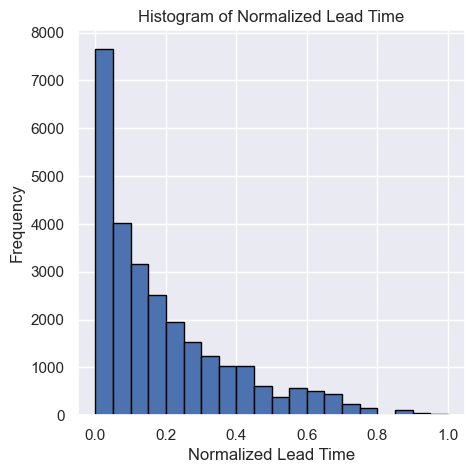

In [38]:
from sklearn.preprocessing import MinMaxScaler
# Initialize the MinMaxScaler
scaler = MinMaxScaler()
# Fit and transform the 'lead_time' column
train_df['lead_time_normalized'] = scaler.fit_transform(train_df[['lead_time']])

# Plot the histogram
plt.hist(train_df['lead_time_normalized'], bins=20, edgecolor='black')
plt.title('Histogram of Normalized Lead Time')
plt.xlabel('Normalized Lead Time')
plt.ylabel('Frequency')
plt.show()

Price: we use z-score normalization.

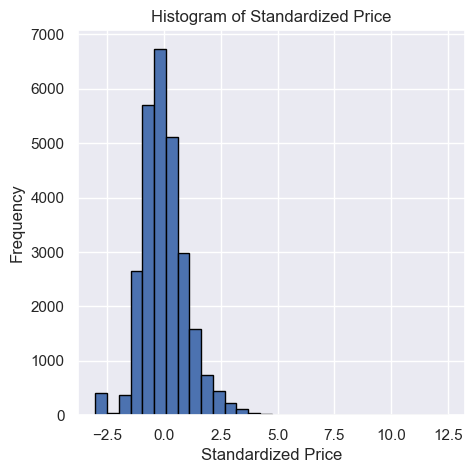

In [39]:
from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler = StandardScaler()
# Fit and transform the 'price' column
train_df['price_standardized'] = scaler.fit_transform(train_df[['price']])
# Plot the histogram
plt.hist(train_df['price_standardized'], bins=30, edgecolor='black')
plt.title('Histogram of Standardized Price')
plt.xlabel('Standardized Price')
plt.ylabel('Frequency')
plt.show()

### Discretization
I won't use it

### Data reduction

#### PCA

In [40]:
from sklearn.decomposition import PCA

Before preforming PCA, we need to change the catagorial columns to numerical

In [41]:
# categorical_columns = ['board_type', 'room_type', 'purchase_type']
train1_df = train_df.copy()
# Create dictionaries to map each category to a unique number
category_mappings = {}
for column in categorical_columns:
    unique_values = train1_df[column].unique()
    category_mappings[column] = {value: index for index, value in enumerate(unique_values)}

# Apply the mappings to convert categorical columns to numerical
for column, mapping in category_mappings.items():
    train1_df[column] = train1_df[column].map(mapping)

# Display the dictionaries to show the mappings (excluding 'ID')
for column, mapping in category_mappings.items():
    print(f"Mapping for {column}: {mapping}")

train1_df = train1_df.drop('ID', axis =1)
train1_df = train1_df.drop('date', axis =1)
train1_df = train1_df.drop('lead_time', axis =1)
train1_df = train1_df.drop('price', axis =1)
print(train1_df.columns)
print(len(train1_df.columns))

Mapping for board_type: {'half board': 0, 'missing': 1, 'full board': 2, 'breakfast': 3}
Mapping for room_type: {'Room_Type 1': 0, 'Room_Type 4': 1, 'Room_Type 6': 2, 'Room_Type 5': 3, 'Room_Type 2': 4, 'Room_Type 7': 5}
Mapping for purchase_type: {'Online': 0, 'missing': 1, 'Offline': 2, 'Corporate': 3, 'Complementary': 4, 'Aviation': 5}
Index(['weekend_nights', 'week_nights', 'room_type', 'board_type', 'n_adults',
       'n_less_12', 'n_more_12', 'booked_tour', 'n_requests', 'purchase_type',
       'n_p_cacellation', 'n_p_not_cacellation', 'repeated', 'is_canceled',
       'length', 'lead_time_normalized', 'price_standardized'],
      dtype='object')
17


In [42]:
# Apply PCA
pca = PCA(n_components=0.999, svd_solver='full')  
pca.fit(train1_df, y= 'is_canceled')
train2_df = pd.DataFrame(pca.transform(train1_df))

# Display the explained variance ratios
print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_)
print(len(pca.explained_variance_ratio_))


Explained variance ratio per component:
[0.36763035 0.22246893 0.10887103 0.06390332 0.0601387  0.05333349
 0.0383282  0.03432941 0.01695068 0.01316441 0.00671431 0.00452501
 0.00435198 0.00219776 0.00197939 0.00111304]
16


No data reduction using PCA

#### Balancing 

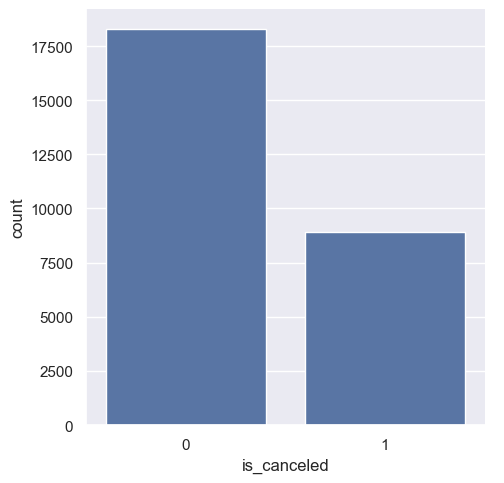

In [43]:
sns.catplot(x = 'is_canceled', kind = 'count', data = train_df)

Because the target values are not balanced, to avoid inaccurate decisions,  we should balance the data. This can be done by:
1. boosting
2. Down Sampeling
3. CSL

For the modeles i chouse CSL can be used.

## Classificators

For this project i chose to use the following classificators that the class covered:
1. Random Forest
2. Decisiom Tree


And CatBoost that was not taught in class



### Random Forest


In [44]:
# imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from pprint import pprint
from sklearn.tree import export_graphviz
from IPython.display import Image  
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn import metrics 


In [45]:
# Create a copy of the preprocessed DataFrame for modeling

# 'is_canceled' is the name of the target column
X = train1_df.drop('is_canceled', axis=1)
y = train1_df['is_canceled']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model on the training data
rf.fit(X_train, y_train)

# Predict on the test data
y_pred_rf = rf.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Report:")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")

Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      3701
           1       0.82      0.75      0.78      1742

    accuracy                           0.87      5443
   macro avg       0.85      0.83      0.84      5443
weighted avg       0.86      0.87      0.86      5443

Accuracy: 0.87


In [46]:
#create grid:
n_estimators = [int(x) for x in np.linspace(start=50, stop=300, num=10)]
max_features = [ 'log2', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 120, num=11)]
min_samples_split = [2, 5, 10,12]
min_samples_leaf = [1, 2, 4, 6]
class_weight = ['balanced']

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'class_weight': class_weight}

#run random forest on the grid
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 6,
                                verbose=2, random_state = 42, n_jobs = -1)

rf_random.fit(X_train, y_train)

Fitting 6 folds for each of 100 candidates, totalling 600 fits


RandomizedSearchCV(cv=6, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced'],
                                        'max_depth': [10, 21, 32, 43, 54, 65,
                                                      76, 87, 98, 109, 120],
                                        'max_features': ['log2', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 12],
                                        'n_estimators': [50, 77, 105, 133, 161,
                                                         188, 216, 244, 272,
                                                         300]},
                   random_state=42, verbose=2)

In [47]:
# predict with the base model

rf_y_pred = rf.predict(X_test)

# Calculate accuracy of the base model
rf_accuracy = metrics.accuracy_score(y_test, rf_y_pred)
print('Base model accuracy: {:0.2f}%'.format(rf_accuracy * 100))

# Fit and predict with the optimized model
best_random = rf_random.best_estimator_
best_random.fit(X_train, y_train)
random_y_pred = best_random.predict(X_test)

# Calculate accuracy of the optimized model
random_accuracy = metrics.accuracy_score(y_test, random_y_pred)
print('Optimized model accuracy: {:0.2f}%'.format(random_accuracy * 100))

# Calculate improvement
improvement = 100 * (random_accuracy - rf_accuracy) / rf_accuracy
print('Improvement: {:0.2f}%'.format(improvement))

Base model accuracy: 86.61%
Optimized model accuracy: 86.63%
Improvement: 0.02%


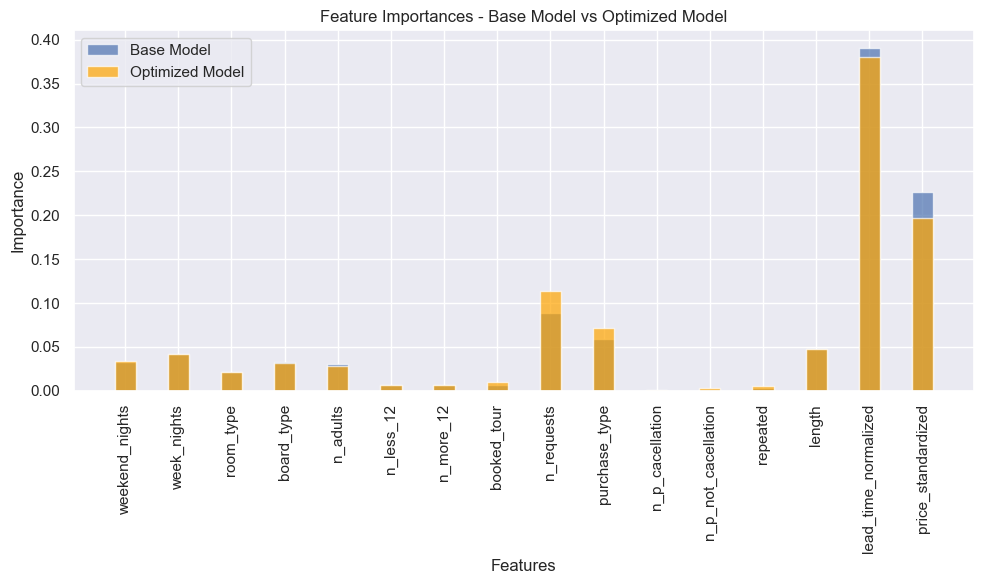

In [48]:
# Extract feature importances from both models
base_importances = rf.feature_importances_
optimized_importances = best_random.feature_importances_

# Create a bar plot to visualize feature importances
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(base_importances))
bar_width = 0.4

ax.bar(x, base_importances, label='Base Model', width=bar_width, alpha=0.7)
ax.bar(x, optimized_importances, label='Optimized Model', width=bar_width, alpha=0.7, color='orange')

ax.set_xticks(x)
ax.set_xticklabels(X.columns, rotation=90)
ax.set_xlabel('Features')
ax.set_ylabel('Importance')
ax.set_title('Feature Importances - Base Model vs Optimized Model')
ax.legend()

# Show the improvement percentage below the plot
plt.tight_layout()
plt.show()

## DT

In [49]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import  GridSearchCV

In [50]:
# Initialize the Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)



# Define the parameter grid for hyperparameter tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [ 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [ 'sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_dt = grid_search.best_estimator_

# Predict on the test data
y_pred_dt = best_dt.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier Report:")
print(classification_report(y_test, y_pred_dt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Decision Tree Classifier Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      3701
           1       0.77      0.68      0.72      1742

    accuracy                           0.83      5443
   macro avg       0.81      0.79      0.80      5443
weighted avg       0.83      0.83      0.83      5443

Accuracy: 0.83
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'best'}


In [51]:
# Fit and predict with the base model
dt.fit(X_train, y_train)
dt_y_pred = dt.predict(X_test)

# Calculate accuracy of the base model
dt_accuracy = metrics.accuracy_score(y_test, dt_y_pred)
print('Base model accuracy: {:0.2f}%'.format(dt_accuracy * 100))


# Calculate accuracy of the optimized model
best_dt_accuracy = metrics.accuracy_score(y_test, y_pred_dt)
print('Optimized model accuracy: {:0.2f}%'.format(best_dt_accuracy * 100))

# Calculate improvement
improvement = 100 * (best_dt_accuracy - dt_accuracy) / dt_accuracy
print('Improvement: {:0.2f}%'.format(improvement))

Base model accuracy: 82.16%
Optimized model accuracy: 83.30%
Improvement: 1.39%


# CatBoost

In [52]:
from catboost import CatBoostClassifier

In [53]:
# Initialize CatBoostClassifier
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=0
)

# Fit the model
catboost_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100)

# Predict on test data
y_pred = catboost_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8631269520485026
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      3701
           1       0.83      0.72      0.77      1742

    accuracy                           0.86      5443
   macro avg       0.85      0.83      0.84      5443
weighted avg       0.86      0.86      0.86      5443



# Model Evaluation

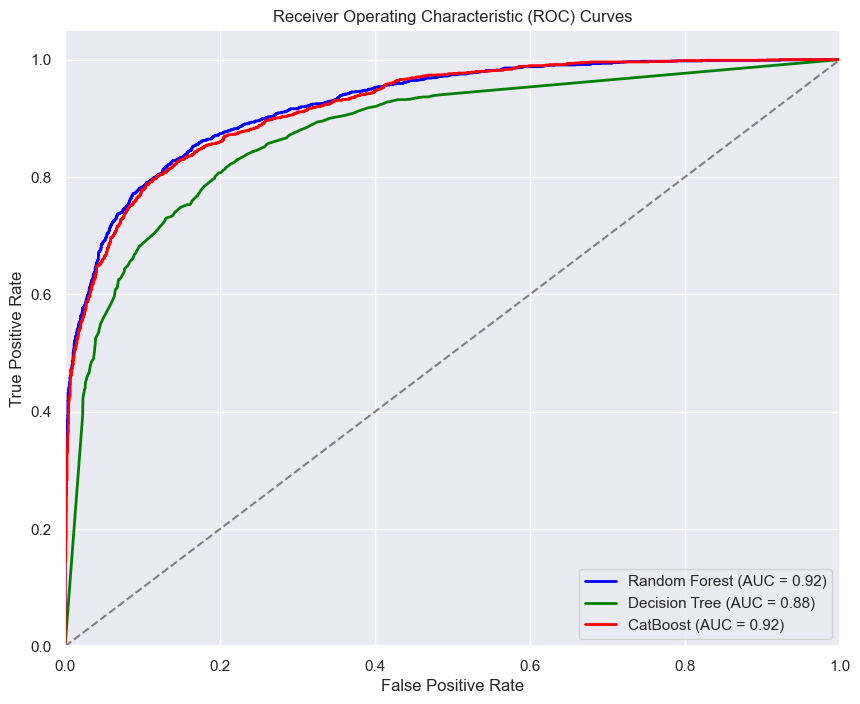

In [54]:
from sklearn.metrics import roc_curve, auc

# Assuming rf_random, best_dt, and catboost_model are your trained models
# and X_test, y_test are your test data and labels

# Get the predicted probabilities
y_pred_rf_prob = rf_random.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_dt_prob = best_dt.predict_proba(X_test)[:, 1]
y_pred_cb_prob = catboost_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calculate ROC curve and AUC for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_prob)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Calculate ROC curve and AUC for CatBoost
fpr_cb, tpr_cb, _ = roc_curve(y_test, y_pred_cb_prob)
roc_auc_cb = auc(fpr_cb, tpr_cb)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_cb, tpr_cb, color='red', lw=2, label=f'CatBoost (AUC = {roc_auc_cb:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

## Cros Validation

In [55]:
from sklearn.model_selection import KFold 
from scipy import stats 

In [56]:

# List of classifiers
clf_list = [rf_random.best_estimator_, best_dt, catboost_model]

# Initialize result dictionaries
result_dict = {}
cm_dict, auc_dict = {}, {}

X = X.to_numpy()  # Ensure X is a NumPy array
y = y.to_numpy()  # Ensure y is a NumPy array

# Initialize KFold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
k = 0

for train_index, test_index in kf.split(X):
    k += 1
    print("------", k, "------")
    
    # Split to train and test
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    for clf in clf_list:
        # Train the model and make predictions
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracy = metrics.accuracy_score(y_test, y_pred)
        precision = metrics.precision_score(y_test, y_pred, average='weighted')  # Added average parameter
        y_probs = clf.predict_proba(X_test)  # Probability prediction
        
        # Calculate AUC
        fpr, tpr, _ = metrics.roc_curve(y_test, y_probs[:, 1])
        auc = metrics.auc(fpr, tpr)
        
        # Use the string representation of the classifier as the key
        clf_name = str(clf)
        
        # Save the results
        clf_dict = result_dict.get(clf_name, {})
        accuracy_list = clf_dict.get('accuracy', [])
        accuracy_list.append(accuracy)
        clf_dict['accuracy'] = accuracy_list
        
        precision_list = clf_dict.get('precision', [])
        precision_list.append(precision)
        clf_dict['precision'] = precision_list
        
        auc_list = clf_dict.get('auc', [])
        auc_list.append(auc)
        clf_dict['auc'] = auc_list
        
        result_dict[clf_name] = clf_dict
        
        # Print the results
        print("Classifier: ", clf_name)
        print("AUC: ", auc)
        print("Accuracy: ", accuracy)

------ 1 ------
Classifier:  RandomForestClassifier(class_weight='balanced', max_depth=21, n_estimators=216,
                       random_state=42)
AUC:  0.9314353757850767
Accuracy:  0.8758265980896399
Classifier:  DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features='sqrt',
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42)
AUC:  0.8835400576975088
Accuracy:  0.8482733284349743
Classifier:  <catboost.core.CatBoostClassifier object at 0x000001CE00F8BEE0>
AUC:  0.9272758461800443
Accuracy:  0.8717854518736223
------ 2 ------
Classifier:  RandomForestClassifier(class_weight='balanced', max_depth=21, n_estimators=216,
                       random_state=42)
AUC:  0.9254803719484286
Accuracy:  0.8655400440852314
Classifier:  DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features='sqrt',
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42)
AUC:  0.873

In [57]:
for clf in clf_list:
    clf_name = str(clf)  # Get the string representation of the classifier
    if clf_name in result_dict:  # Check if the key exists
        accuracy_list = result_dict[clf_name]['accuracy']
        print("mean accuracy for", clf_name, ":", np.mean(accuracy_list))
        
        precision_list = result_dict[clf_name]['precision']
        print("mean precision for", clf_name, ":", np.mean(precision_list))
        
        auc_list = result_dict[clf_name]['auc']
        print("mean auc for", clf_name, ":", np.mean(auc_list))
    else:
        print("Results for", clf_name, "not found.")

mean accuracy for RandomForestClassifier(class_weight='balanced', max_depth=21, n_estimators=216,
                       random_state=42) : 0.8643656800550648
mean precision for RandomForestClassifier(class_weight='balanced', max_depth=21, n_estimators=216,
                       random_state=42) : 0.8628645519223859
mean auc for RandomForestClassifier(class_weight='balanced', max_depth=21, n_estimators=216,
                       random_state=42) : 0.9268350681058
mean accuracy for DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features='sqrt',
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42) : 0.8359968093158472
mean precision for DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features='sqrt',
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42) : 0.8333659053259612
mean auc for DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features

### Statistical Significance Tests
Two-sided test for the null hypothesis that two related or repeated samples have identical average (expected) values.

In [58]:
# clf_list = [rf_random.best_estimator_, best_dt, catboost_model]

def get_clf_name(clf):
    return clf.__class__.__name__

# Perform paired t-tests between all pairs of classifiers
for i in range(len(clf_list)):
    for j in range(i + 1, len(clf_list)):
        clf_a = clf_list[i]
        clf_b = clf_list[j]
        
        clf_a_name = str(clf_a)
        clf_b_name = str(clf_b)
        
        # Check if results are available for both classifiers
        if clf_a_name in result_dict and clf_b_name in result_dict:
            precision_a = result_dict[clf_a_name]['precision']
            precision_b = result_dict[clf_b_name]['precision']
            
            accuracy_a = result_dict[clf_a_name]['accuracy']
            accuracy_b = result_dict[clf_b_name]['accuracy']
            
            auc_a = result_dict[clf_a_name]['auc']
            auc_b = result_dict[clf_b_name]['auc']
            
            # Perform paired t-tests
            print(f"Comparing {clf_a_name} and {clf_b_name}:")
            
            # Precision
            ttest, pval = stats.ttest_rel(precision_a, precision_b)
            print("Precision p-value:", pval)
            if pval < 0.05:
                print("Reject null hypothesis: There is a significant difference in precision.")
            else:
                print("Accept null hypothesis: No significant difference in precision.")
            
            # Accuracy
            ttest, pval = stats.ttest_rel(accuracy_a, accuracy_b)
            print("Accuracy p-value:", pval)
            if pval < 0.05:
                print("Reject null hypothesis: There is a significant difference in accuracy.")
            else:
                print("Accept null hypothesis: No significant difference in accuracy.")
            
            # AUC
            ttest, pval = stats.ttest_rel(auc_a, auc_b)
            print("AUC p-value:", pval)
            if pval < 0.05:
                print("Reject null hypothesis: There is a significant difference in AUC.")
            else:
                print("Accept null hypothesis: No significant difference in AUC.")
            
            print()
        else:
            print(f"Results for {clf_a_name} or {clf_b_name} not found.")

Comparing RandomForestClassifier(class_weight='balanced', max_depth=21, n_estimators=216,
                       random_state=42) and DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features='sqrt',
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42):
Precision p-value: 1.3447636415486927e-07
Reject null hypothesis: There is a significant difference in precision.
Accuracy p-value: 1.5217464707889645e-07
Reject null hypothesis: There is a significant difference in accuracy.
AUC p-value: 5.238768471316712e-12
Reject null hypothesis: There is a significant difference in AUC.

Comparing RandomForestClassifier(class_weight='balanced', max_depth=21, n_estimators=216,
                       random_state=42) and <catboost.core.CatBoostClassifier object at 0x000001CE00F8BEE0>:
Precision p-value: 0.19220625011210543
Accept null hypothesis: No significant difference in precision.
Accuracy p-value: 0.19985826358547829
Accept null h

Wanting to maximize AUC, choosing Random Forest

## Test Dataset

Reading the test data

In [59]:
test_df = pd.read_csv("hotels_test.csv")

Fill nulls

In [60]:
test_df['board_type'] = test_df['board_type'].fillna('missing')

In [61]:
# Calculate the median lead time
LT_median = test_df['lead_time'].median()
# Fill missing values in the lead_time column with the median
test_df['lead_time'] = test_df['lead_time'].fillna(LT_median)

In [62]:
test_df['purchase_type'] = test_df['purchase_type'].fillna('missing')

In [63]:
fill_with_mean = ['Room_Type 7','Room_Type 2','Room_Type 5','Room_Type 6']
fill_with_normal = ['Room_Type 1','Room_Type 4']

# Finding the distributions
mu1 = test_df.loc[test_df['room_type']=='Room_Type 1', 'price'].mean()
sigma1 = test_df.loc[test_df['room_type']=='Room_Type 1', 'price'].std()

mu4 = test_df.loc[test_df['room_type']=='Room_Type 4', 'price'].mean()
sigma4 = test_df.loc[test_df['room_type']=='Room_Type 4', 'price'].std()

# Filling the values:
def fill_missing_price1(row):
    if pd.isna(row['price']) and row['room_type'] == 'Room_Type 1':
        return np.random.normal(mu1, sigma1)
    else:
        return row['price']

test_df['price'] = test_df.apply(fill_missing_price1, axis=1)

def fill_missing_price4(row):
    if pd.isna(row['price']) and row['room_type'] == 'Room_Type 4':
        return np.random.normal(mu4, sigma4)
    else:
        return row['price']

test_df['price'] = test_df.apply(fill_missing_price4, axis=1)

# Filling with mean:
for type_room in fill_with_mean:
    mean_price = test_df.loc[test_df['room_type'] == type_room, 'price'].mean()
    test_df.loc[(test_df['room_type'] == type_room) & (test_df['price'].isnull()), 'price'] = mean_price

Add 'length' column

In [64]:
test_df['length'] = test_df['week_nights'] + test_df['weekend_nights']

Changing outlier catagories

In [65]:
train_df['board_type'] = train_df['board_type'].replace('not selected', 'missing')

In [72]:
# Calculate the mean prices for each room type
filtered_df = test_df[test_df['room_type'] != 'Room_Type 3']

# Calculate the mean prices for each room type excluding 'Room_Type 3'
mean_prices = filtered_df.groupby('room_type')['price'].mean()

# Function to find the closest room type based on price
def find_closest_room_type(price):
    closest_room_type = mean_prices.sub(price).abs().idxmin()
    return closest_room_type

# Update the room_type for rows where room_type is Room_Type 3
test_df.loc[test_df['room_type'] == 'Room_Type 3', 'room_type'] = test_df.loc[test_df['room_type'] == 'Room_Type 3', 'price'].apply(find_closest_room_type)

C:\Users\user\AppData\Local\Temp\ipykernel_11352\237610594.py:9: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  closest_room_type = mean_prices.sub(price).abs().idxmin()


Normalization

In [73]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler()
# Fit and transform the 'lead_time' column
test_df['lead_time_normalized'] = scaler.fit_transform(test_df[['lead_time']])
test_df =test_df.drop('lead_time', axis =1)

In [74]:
# Initialize the StandardScaler
scaler = StandardScaler()
# Fit and transform the 'price' column
test_df['price_standardized'] = scaler.fit_transform(test_df[['price']])

test_df =test_df.drop('price', axis =1)

In [75]:
test_df = test_df.drop('ID', axis =1)
test_df = test_df.drop('date', axis =1)


#### Numerate

In [76]:
# Create dictionaries to map each category to a unique number
category_mappings = {}
for column in categorical_columns:
    unique_values = test_df[column].unique()
    category_mappings[column] = {value: index for index, value in enumerate(unique_values)}

# Apply the mappings to convert categorical columns to numerical
for column, mapping in category_mappings.items():
    test_df[column] = test_df[column].map(mapping)

# Display the dictionaries to show the mappings (excluding 'ID')
for column, mapping in category_mappings.items():
    print(f"Mapping for {column}: {mapping}")

Mapping for board_type: {'missing': 0, 'half board': 1, 'breakfast': 2, 'full board': 3}
Mapping for room_type: {'Room_Type 4': 0, 'Room_Type 2': 1, 'Room_Type 7': 2, 'Room_Type 1': 3, 'Room_Type 6': 4, 'Room_Type 5': 5, nan: 6}
Mapping for purchase_type: {'Online': 0, 'missing': 1, 'Offline': 2, 'Aviation': 3, 'Corporate': 4, 'Complementary': 5}


### Predicting

In [77]:
X_test = test_df  # Assuming all columns in test_df are features

# 2. Make Predictions
best_random = rf_random.best_estimator_
predictions = best_random.predict(X_test)

# 3. Create a DataFrame with predictions
# Create a DataFrame with the predictions
results_df = pd.DataFrame({
    'prediction': predictions
})

# Optionally, if you want to include identifiers or other columns from test_df
results_df = test_df.copy()
results_df['prediction'] = predictions


results_df.describe()

output_csv = results_df['prediction']

# Count the number of positive and negative predictions
positive_predictions = results_df['prediction'].value_counts()[1]
negative_predictions = results_df['prediction'].value_counts()[0]

# Print the results
print("Number of positive predictions:", positive_predictions)
print("Number of negative predictions:", negative_predictions)


# 4. Save the results to a CSV file
output_csv.to_csv('predictions.csv', index=False)

c:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Number of positive predictions: 2350
Number of negative predictions: 6722
